In [0]:
from pyspark.sql import functions as F

db_host = dbutils.secrets.get(scope="mortalidad-dw", key="host")
db_port = dbutils.secrets.get(scope="mortalidad-dw", key="port")
db_name = dbutils.secrets.get(scope="mortalidad-dw", key="database")
db_user = dbutils.secrets.get(scope="mortalidad-dw", key="user")
db_password = dbutils.secrets.get(scope="mortalidad-dw", key="password")

jdbc_url = f"jdbc:postgresql://{db_host}:{db_port}/{db_name}"

connection_properties = {
    "user": db_user,
    "password": db_password,
    "driver": "org.postgresql.Driver"
}


In [0]:
# CREAR QUERY DE MORTALIDAD
query_mortalidad = """
(
    SELECT
        g.iso3c,
        g.nombre_pais,
        g.region,
        t.anio,
        t.mes,
        SUM(f.deaths) AS muertes_observadas
    FROM dw.fact_mortalidad_mundial f
    INNER JOIN dw.dim_tiempo t
        ON f.id_tiempo = t.id_tiempo
    INNER JOIN dw.dim_geografia_mundial g
        ON f.id_geografia_mundial = g.id_geografia_mundial
    WHERE t.anio BETWEEN 2015 AND 2024
      AND t.mes BETWEEN 0 AND 12
      AND f.deaths IS NOT NULL
    GROUP BY
        g.iso3c,
        g.nombre_pais,
        g.region,
        t.anio,
        t.mes
) AS mortalidad_ml
"""

df_mortalidad = spark.read.jdbc(
    url=jdbc_url,
    table=query_mortalidad,
    properties=connection_properties
)

display(df_mortalidad.limit(50))

iso3c,nombre_pais,region,anio,mes,muertes_observadas
NIC,Nicaragua,Centroamerica,2019,10,2345.000000000000000000
UKR,Ukraine,Europa,2017,5,51274.000000000000000000
CAN,Canada,Norteamerica,2023,0,327320.000000000000000000
ARG,Argentina,Sudamerica,2015,5,27609.000000000000000000
UKR,Ukraine,Europa,2015,9,43642.000000000000000000
RUS,Russia,Europa,2015,11,151481.000000000000000000
KOR,South Korea,Asia-Oceania,2023,0,257797.000000000000000000
RUS,Russia,Europa,2017,6,148641.000000000000000000
CRI,Costa Rica,Centroamerica,2016,11,2021.000000000000000000
SLV,El Salvador,Centroamerica,2019,12,2505.000000000000000000


In [0]:
import pandas as pd
import numpy as np

df = df_mortalidad.toPandas()

df["anio"] = df["anio"].astype(int)
df["mes"] = df["mes"].astype(int)
df["muertes_observadas"] = pd.to_numeric(df["muertes_observadas"], errors="coerce")

df = df.dropna(subset=["iso3c", "anio", "mes", "muertes_observadas"])

df.head()

,iso3c,nombre_pais,region,anio,mes,muertes_observadas
0,NIC,Nicaragua,Centroamerica,2019,10,2345.0
1,UKR,Ukraine,Europa,2017,5,51274.0
2,CAN,Canada,Norteamerica,2023,0,327320.0
3,ARG,Argentina,Sudamerica,2015,5,27609.0
4,UKR,Ukraine,Europa,2015,9,43642.0


In [0]:
df_pre = df[(df["anio"] >= 2015) & (df["anio"] <= 2019)]

baseline = (
    df_pre
    .groupby(["iso3c", "mes"], as_index=False)
    .agg(
        promedio_pre_covid=("muertes_observadas", "mean"),
        desviacion_pre_covid=("muertes_observadas", "std")
    )
)

df_modelo = df.merge(baseline, on=["iso3c", "mes"], how="left")

df_modelo["desviacion_pre_covid"] = df_modelo["desviacion_pre_covid"].fillna(0)

df_modelo["exceso_pct"] = (
    (df_modelo["muertes_observadas"] - df_modelo["promedio_pre_covid"])
    / df_modelo["promedio_pre_covid"]
)

df_modelo["exceso_mortalidad"] = np.where(
    df_modelo["exceso_pct"] >= 0.15,
    1,
    0
)

df_modelo = df_modelo.dropna(subset=["promedio_pre_covid", "exceso_mortalidad"])

df_modelo[[
    "iso3c",
    "nombre_pais",
    "region",
    "anio",
    "mes",
    "muertes_observadas",
    "promedio_pre_covid",
    "exceso_pct",
    "exceso_mortalidad"
]].head(20)

,iso3c,nombre_pais,region,anio,mes,muertes_observadas,promedio_pre_covid,exceso_pct,exceso_mortalidad
0,NIC,Nicaragua,Centroamerica,2019,10,2345.0,2123.2,0.104465,0
1,UKR,Ukraine,Europa,2017,5,51274.0,51095.8,0.003488,0
2,CAN,Canada,Norteamerica,2023,0,327320.0,276422.0,0.184132,1
3,ARG,Argentina,Sudamerica,2015,5,27609.0,29418.4,-0.061506,0
4,UKR,Ukraine,Europa,2015,9,43642.0,42430.4,0.028555,0
5,RUS,Russia,Europa,2015,11,151481.0,146389.2,0.034783,0
6,KOR,South Korea,Asia-Oceania,2023,0,257797.0,287336.2,-0.102804,0
7,RUS,Russia,Europa,2017,6,148641.0,151004.8,-0.015654,0
8,CRI,Costa Rica,Centroamerica,2016,11,2021.0,1953.0,0.034818,0
9,SLV,El Salvador,Centroamerica,2019,12,2505.0,2624.4,-0.045496,0


In [0]:
df_modelo["exceso_mortalidad"].value_counts()

exceso_mortalidad
0    1130
1     305
Name: count, dtype: int64

In [0]:
df_modelo["exceso_mortalidad"].value_counts(normalize=True) * 100

exceso_mortalidad
0    78.745645
1    21.254355
Name: proportion, dtype: float64

In [0]:
# entrenar Regresión Logística
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

features = [
    "iso3c",
    "region",
    "anio",
    "mes",
    "promedio_pre_covid",
    "desviacion_pre_covid"
]

target = "exceso_mortalidad"

df_ml = df_modelo[features + [target]].copy()
df_ml = df_ml.dropna()

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

categorical_features = ["iso3c", "region"]
numeric_features = ["anio", "mes", "promedio_pre_covid", "desviacion_pre_covid"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['iso3c', 'region']),
                                                 ('num', StandardScaler(),
                                                  ['anio', 'mes',
                                                   'promedio_pre_covid',
                                                   'desviacion_pre_covid'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

# Gráfica 1: exceso real de mortalidad por región

region,total_observaciones,casos_exceso,promedio_exceso_pct,porcentaje_con_exceso
Norteamerica,29,9,10.60289583645248,31.03448275862069
Centroamerica,502,122,9.493992335463076,24.302788844621514
Asia-Oceania,269,65,8.744074984127673,24.1635687732342
Sudamerica,350,84,11.511873744793276,24.0
Europa,285,25,4.241022892095147,8.771929824561402


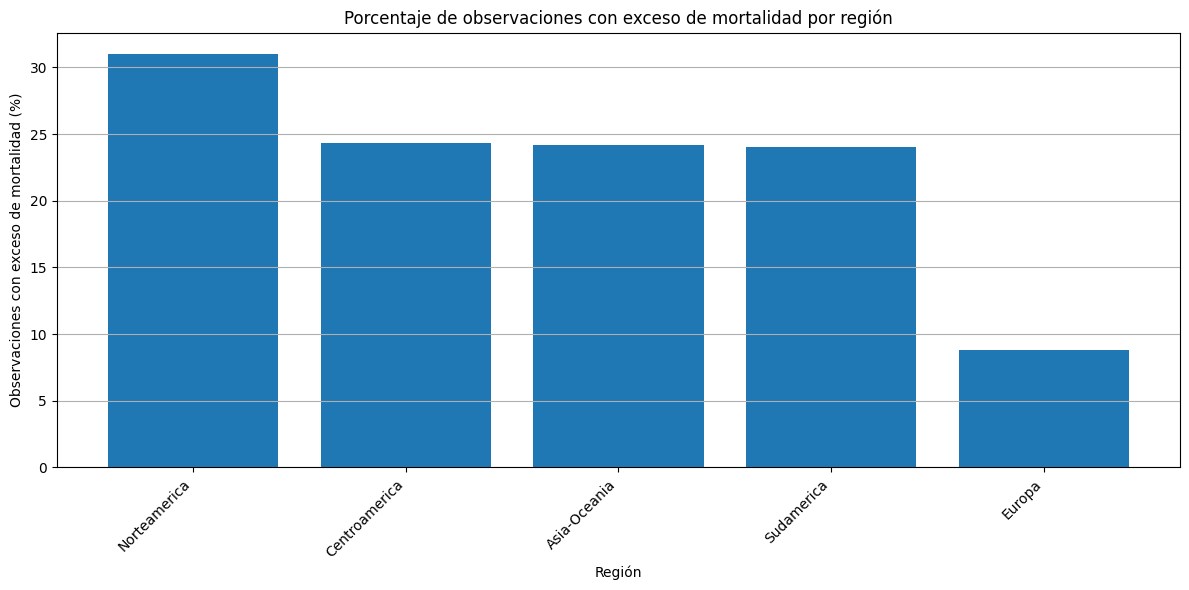

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Gráfica 1: Porcentaje real de exceso de mortalidad por región
# ============================================================

df_region = df_modelo.copy()

df_region["region"] = df_region["region"].fillna("Sin región")

resumen_region = (
    df_region
    .groupby("region", as_index=False)
    .agg(
        total_observaciones=("exceso_mortalidad", "count"),
        casos_exceso=("exceso_mortalidad", "sum"),
        promedio_exceso_pct=("exceso_pct", "mean")
    )
)

resumen_region["porcentaje_con_exceso"] = (
    resumen_region["casos_exceso"] / resumen_region["total_observaciones"]
) * 100

resumen_region["promedio_exceso_pct"] = resumen_region["promedio_exceso_pct"] * 100

resumen_region = resumen_region.sort_values(
    "porcentaje_con_exceso",
    ascending=False
)

display(resumen_region)

plt.figure(figsize=(12, 6))

plt.bar(
    resumen_region["region"],
    resumen_region["porcentaje_con_exceso"]
)

plt.title("Porcentaje de observaciones con exceso de mortalidad por región")
plt.xlabel("Región")
plt.ylabel("Observaciones con exceso de mortalidad (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfica 2: probabilidad predicha por el modelo por región

region,total_registros,predicciones_exceso,probabilidad_promedio,porcentaje_predicho_exceso
Sudamerica,81,31,42.93753836518987,38.2716049382716
Centroamerica,139,51,40.12052824232924,36.69064748201439
Asia-Oceania,64,18,37.78173305797236,28.125
Norteamerica,5,1,26.79339691018393,20.0
Europa,70,14,23.94341465955058,20.0


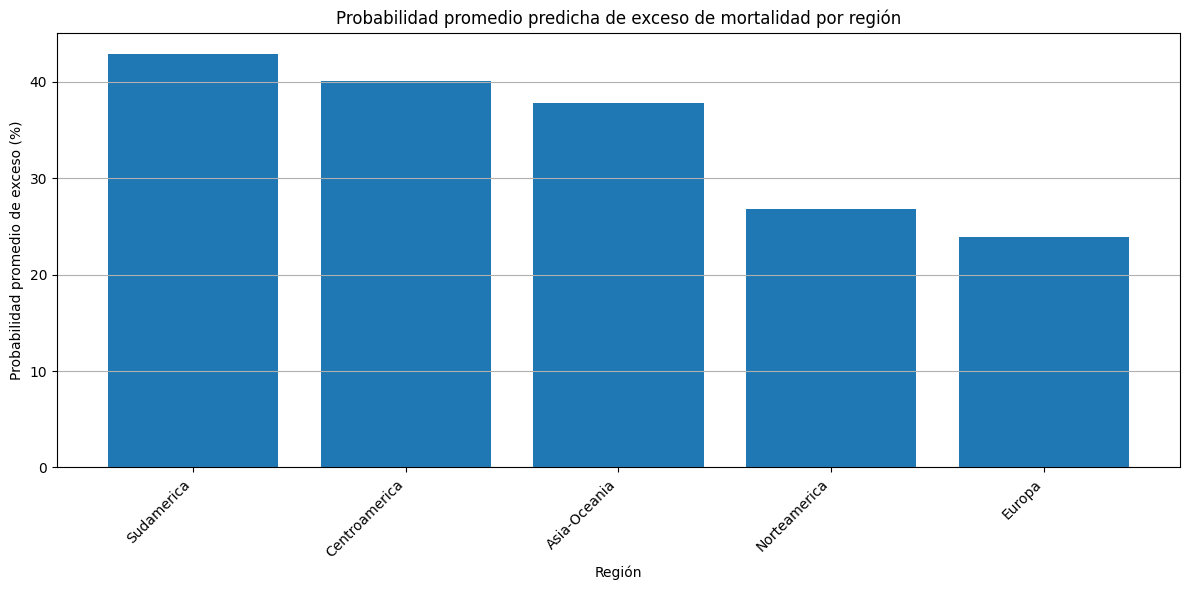

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Gráfica 2: Probabilidad promedio predicha de exceso por región
# ============================================================

umbral_final = 0.55

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= umbral_final).astype(int)

df_eval_region = X_test.copy().reset_index(drop=True)

df_eval_region["real_exceso"] = pd.Series(y_test).reset_index(drop=True)
df_eval_region["pred_exceso"] = y_pred
df_eval_region["probabilidad_exceso"] = y_proba

df_eval_region["region"] = df_eval_region["region"].fillna("Sin región")

resumen_pred_region = (
    df_eval_region
    .groupby("region", as_index=False)
    .agg(
        total_registros=("pred_exceso", "count"),
        predicciones_exceso=("pred_exceso", "sum"),
        probabilidad_promedio=("probabilidad_exceso", "mean")
    )
)

resumen_pred_region["porcentaje_predicho_exceso"] = (
    resumen_pred_region["predicciones_exceso"] / resumen_pred_region["total_registros"]
) * 100

resumen_pred_region["probabilidad_promedio"] = (
    resumen_pred_region["probabilidad_promedio"] * 100
)

resumen_pred_region = resumen_pred_region.sort_values(
    "probabilidad_promedio",
    ascending=False
)

display(resumen_pred_region)

plt.figure(figsize=(12, 6))

plt.bar(
    resumen_pred_region["region"],
    resumen_pred_region["probabilidad_promedio"]
)

plt.title("Probabilidad promedio predicha de exceso de mortalidad por región")
plt.xlabel("Región")
plt.ylabel("Probabilidad promedio de exceso (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

anio,total_muertes_observadas,promedio_historico_pre_covid,exceso_pct_anual,supera_promedio
2015,82265.0,82799.6,-0.006456552930207462,false
2016,82140.0,82799.6,-0.007966222059043833,false
2017,81434.0,82799.6,-0.016492833298711658,false
2018,82817.0,82799.6,2.1014594273395255E-4,true
2019,85342.0,82799.6,0.030705462345228647,true
2020,97447.0,82799.6,0.17690182078174282,true
2021,118163.0,82799.6,0.4270962661655369,true
2022,95058.0,82799.6,0.1480490243914221,true
2023,95644.0,82799.6,0.155126353267407,true
2024,99051.0,82799.6,0.19627389504297113,true


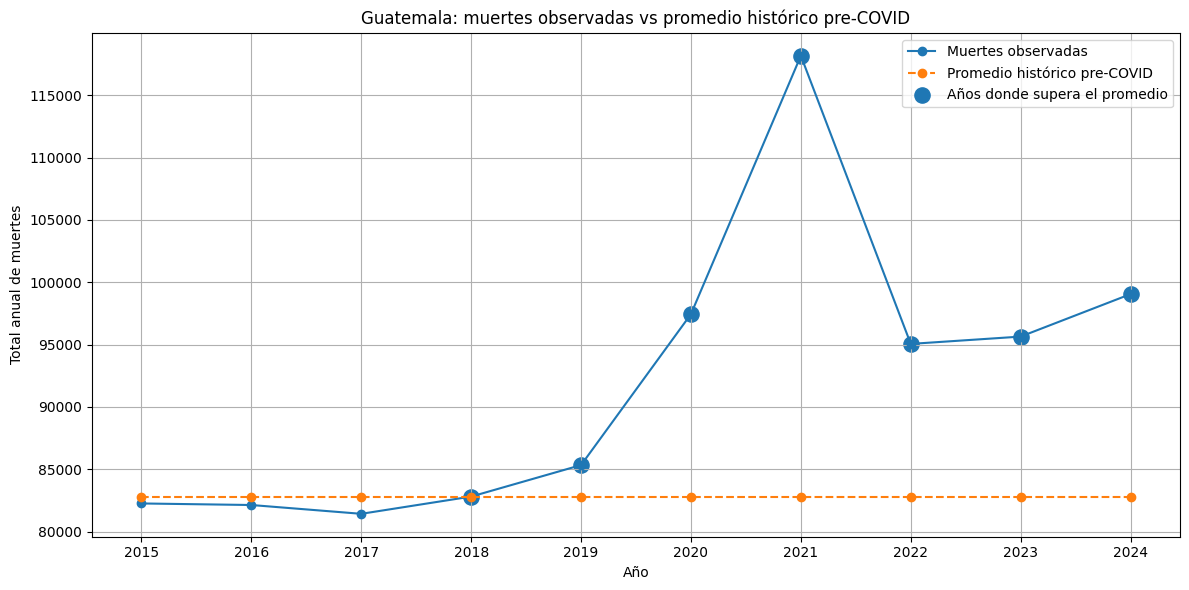

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Gráfica: Mortalidad observada vs promedio histórico pre-COVID
# País objetivo: Guatemala
# ============================================================

pais_objetivo = "GTM"

# Filtrar datos de Guatemala
df_gt = df_modelo[df_modelo["iso3c"] == pais_objetivo].copy()

# Validación por si no encuentra GTM
if df_gt.empty:
    raise ValueError("No se encontraron datos para Guatemala con iso3c = 'GTM'. Verifica si el país existe en df_modelo.")

# Asegurar tipos numéricos
df_gt["anio"] = df_gt["anio"].astype(int)
df_gt["mes"] = df_gt["mes"].astype(int)
df_gt["muertes_observadas"] = pd.to_numeric(df_gt["muertes_observadas"], errors="coerce")
df_gt["promedio_pre_covid"] = pd.to_numeric(df_gt["promedio_pre_covid"], errors="coerce")

# Agrupar por año
# muertes_observadas: total real anual
# promedio_pre_covid: suma de los promedios mensuales pre-COVID, para obtener línea base anual
df_gt_anual = (
    df_gt
    .groupby("anio", as_index=False)
    .agg(
        total_muertes_observadas=("muertes_observadas", "sum"),
        promedio_historico_pre_covid=("promedio_pre_covid", "sum")
    )
)

# Calcular exceso porcentual anual
df_gt_anual["exceso_pct_anual"] = (
    (df_gt_anual["total_muertes_observadas"] - df_gt_anual["promedio_historico_pre_covid"])
    / df_gt_anual["promedio_historico_pre_covid"]
)

# Marcar años donde supera el promedio histórico pre-COVID
df_gt_anual["supera_promedio"] = (
    df_gt_anual["total_muertes_observadas"] > df_gt_anual["promedio_historico_pre_covid"]
)

display(df_gt_anual)

# ============================================================
# Gráfica de líneas
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df_gt_anual["anio"],
    df_gt_anual["total_muertes_observadas"],
    marker="o",
    label="Muertes observadas"
)

plt.plot(
    df_gt_anual["anio"],
    df_gt_anual["promedio_historico_pre_covid"],
    marker="o",
    linestyle="--",
    label="Promedio histórico pre-COVID"
)

# Resaltar años donde las muertes observadas superan el promedio histórico
df_supera = df_gt_anual[df_gt_anual["supera_promedio"] == True]

plt.scatter(
    df_supera["anio"],
    df_supera["total_muertes_observadas"],
    s=120,
    label="Años donde supera el promedio"
)

plt.title("Guatemala: muertes observadas vs promedio histórico pre-COVID")
plt.xlabel("Año")
plt.ylabel("Total anual de muertes")
plt.xticks(df_gt_anual["anio"])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
paises_disponibles = (
    df_modelo[["iso3c", "nombre_pais", "region"]]
    .drop_duplicates()
    .sort_values(["region", "nombre_pais"])
    .reset_index(drop=True)
)

display(paises_disponibles)

iso3c,nombre_pais,region
AUS,Australia,Asia-Oceania
JPN,Japan,Asia-Oceania
NZL,New Zealand,Asia-Oceania
KOR,South Korea,Asia-Oceania
TUR,Turkey,Asia-Oceania
BLZ,Belize,Centroamerica
CRI,Costa Rica,Centroamerica
SLV,El Salvador,Centroamerica
GTM,Guatemala,Centroamerica
NIC,Nicaragua,Centroamerica


# PROBAR CON VARIOS HUMBRALES

In [0]:
resultados_umbral = []

y_proba = model.predict_proba(X_test)[:, 1]

umbrales = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)

    accuracy = accuracy_score(y_test, y_pred_umbral)
    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test, y_pred_umbral, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_umbral)

    tn, fp, fn, tp = cm.ravel()

    resultados_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp
    })

df_umbrales = pd.DataFrame(resultados_umbral)

display(df_umbrales)

umbral,accuracy,precision,recall,f1,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos
0.4,0.7604456824512534,0.46794871794871795,0.9605263157894737,0.6293103448275862,200,83,3,73
0.45,0.7883008356545961,0.5,0.9342105263157895,0.6513761467889908,212,71,5,71
0.5,0.8189415041782729,0.5433070866141733,0.9078947368421053,0.6798029556650246,225,58,7,69
0.55,0.8245125348189415,0.5565217391304348,0.8421052631578947,0.6701570680628273,232,51,12,64
0.6,0.83008356545961,0.5728155339805825,0.7763157894736842,0.659217877094972,239,44,17,59
0.65,0.8384401114206128,0.5978260869565217,0.7236842105263158,0.6547619047619048,246,37,21,55
0.7,0.841225626740947,0.6172839506172839,0.6578947368421053,0.6369426751592356,252,31,26,50
0.75,0.8272980501392758,0.6,0.5526315789473685,0.5753424657534246,255,28,34,42


# El mejor es el humbral de 0.50
Se evaluaron distintos umbrales de decisión entre 0.40 y 0.75. Aunque el umbral 0.65 obtuvo el mayor accuracy, se seleccionó el umbral 0.50 porque presentó el mejor F1-score y mantuvo un recall alto para la clase de exceso de mortalidad. Esto permite reducir falsos positivos sin sacrificar demasiado la detección de casos reales de exceso.

In [0]:
y_pred = model.predict(X_test)
umbral_final = 0.5

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= umbral_final).astype(int)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Umbral final:", umbral_final)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Matriz de confusión:")
print(cm)

print(classification_report(y_test, y_pred, zero_division=0))

Umbral final: 0.5
Accuracy: 0.8189415041782729
Precision: 0.5433070866141733
Recall: 0.9078947368421053
F1: 0.6798029556650246
Matriz de confusión:
[[225  58]
 [  7  69]]
              precision    recall  f1-score   support

           0       0.97      0.80      0.87       283
           1       0.54      0.91      0.68        76

    accuracy                           0.82       359
   macro avg       0.76      0.85      0.78       359
weighted avg       0.88      0.82      0.83       359



#Exportar el modelo tar (Buscarlo en Workspace -> users -> correo -> modelos_ml)

In [0]:
import os
import json
import tarfile
import joblib
import shutil
import base64
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Métricas finales con umbral seleccionado

umbral_final = 0.5

# Probabilidad de la clase 1 = exceso de mortalidad
y_proba = model.predict_proba(X_test)[:, 1]

# Predicción final usando el umbral seleccionado
y_pred = (y_proba >= umbral_final).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Umbral final:", umbral_final)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Matriz de confusión:")
print(cm)
print(classification_report(y_test, y_pred, zero_division=0))

# 2. Carpeta temporal local con permisos

output_dir = "/tmp/modelo_exceso_mortalidad"
os.makedirs(output_dir, exist_ok=True)

model_path = f"{output_dir}/modelo_logreg.joblib"
metrics_path = f"{output_dir}/metricas_modelo.json"
confusion_path = f"{output_dir}/matriz_confusion.csv"
thresholds_path = f"{output_dir}/comparacion_umbrales.csv"
coefficients_path = f"{output_dir}/coeficientes_modelo.csv"
readme_path = f"{output_dir}/README_modelo.txt"

# 3. Guardar modelo entrenado

joblib.dump(model, model_path)

# 4. Guardar métricas del modelo

metricas = {
    "modelo": "Regresion Logistica",
    "problema": "Clasificacion binaria de exceso de mortalidad",
    "variable_objetivo": "exceso_mortalidad",
    "definicion_exceso": "1 si muertes_observadas >= 15% sobre el promedio historico pre-COVID 2015-2019",
    "umbral_decision": float(umbral_final),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "matriz_confusion": cm.tolist(),
    "features": features,
    "fecha_exportacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "herramienta": "Databricks",
    "libreria_modelo": "scikit-learn",
    "observacion": "Se selecciono el umbral 0.55 por presentar mejor balance entre F1-score y recall."
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)

# 5. Guardar matriz de confusión

df_confusion = pd.DataFrame(
    cm,
    columns=["Pred_No_Exceso", "Pred_Exceso"],
    index=["Real_No_Exceso", "Real_Exceso"]
)

df_confusion.to_csv(confusion_path, encoding="utf-8")

# 6. Guardar comparación de umbrales

try:
    df_umbrales.to_csv(thresholds_path, index=False, encoding="utf-8")
except NameError:
    pd.DataFrame({
        "nota": ["No se genero df_umbrales en esta ejecucion."]
    }).to_csv(thresholds_path, index=False, encoding="utf-8")


# 7. Guardar coeficientes / pesos del modelo

try:
    preprocessor_export = model.named_steps["preprocessor"]
    classifier_export = model.named_steps["classifier"]

    feature_names = preprocessor_export.get_feature_names_out()
    coefficients = classifier_export.coef_[0]
    intercept = classifier_export.intercept_[0]

    df_coeficientes = pd.DataFrame({
        "feature": feature_names,
        "coeficiente_peso": coefficients
    })

    df_coeficientes["intercept_bias"] = intercept

    df_coeficientes.to_csv(coefficients_path, index=False, encoding="utf-8")

except Exception as e:
    pd.DataFrame({
        "error": [str(e)]
    }).to_csv(coefficients_path, index=False, encoding="utf-8")

# 8. Crear README del modelo

readme_text = f"""
Modelo de Machine Learning - Regresion Logistica

Problema:
Clasificacion binaria de exceso de mortalidad.

Variable objetivo:
exceso_mortalidad

Definicion:
La variable objetivo toma valor 1 cuando las muertes observadas superan en al menos 15%
el promedio historico pre-COVID 2015-2019 para el mismo pais y mes. En caso contrario,
toma valor 0.

Modelo:
Regresion Logistica entrenada en Databricks usando scikit-learn.

Umbral de decision:
{umbral_final}

Metricas finales:
Accuracy: {accuracy}
Precision: {precision}
Recall: {recall}
F1-score: {f1}

Matriz de confusion:
{cm}

Archivos incluidos:
- modelo_logreg.joblib
- metricas_modelo.json
- matriz_confusion.csv
- comparacion_umbrales.csv
- coeficientes_modelo.csv
- README_modelo.txt

Seguridad:
No se incluyen credenciales ni secrets dentro de este archivo.
La conexion al DW se realizo mediante dbutils.secrets.get().
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)



# Guardar lista de columnas usadas por el modelo
feature_columns_path = f"{output_dir}/feature_columns.joblib"
baseline_path = f"{output_dir}/baseline_pre_covid.csv"

joblib.dump(features, feature_columns_path)
baseline.to_csv(baseline_path, index=False, encoding="utf-8")

# 9. Comprimir todo en .tar.gz



tar_path = "/tmp/modelo_exceso_mortalidad_logreg.tar.gz"

with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(model_path, arcname="modelo_logreg.joblib")
    tar.add(feature_columns_path, arcname="feature_columns.joblib")
    tar.add(metrics_path, arcname="metricas_modelo.json")
    tar.add(confusion_path, arcname="matriz_confusion.csv")
    tar.add(thresholds_path, arcname="comparacion_umbrales.csv")
    tar.add(coefficients_path, arcname="coeficientes_modelo.csv")
    tar.add(readme_path, arcname="README_modelo.txt")
    tar.add(baseline_path, arcname="baseline_pre_covid.csv")

print("Modelo comprimido correctamente:")
print(tar_path)
print("Existe archivo:", os.path.exists(tar_path))
print("Tamaño bytes:", os.path.getsize(tar_path))

# 10. Copiar a Workspace Files

workspace_user_dir = "/Workspace/Users/" + spark.sql("SELECT current_user()").collect()[0][0]
workspace_model_dir = workspace_user_dir + "/modelos_ml"

os.makedirs(workspace_model_dir, exist_ok=True)

workspace_tar_path = workspace_model_dir + "/modelo_exceso_mortalidad_logreg.tar.gz"

shutil.copyfile(tar_path, workspace_tar_path)

print("Archivo copiado a Workspace Files:")
print(workspace_tar_path)
print("Existe en workspace:", os.path.exists(workspace_tar_path))
print("Tamaño bytes:", os.path.getsize(workspace_tar_path))

# 11. Botón de descarga directa desde el notebook

filename = "modelo_exceso_mortalidad_logreg.tar.gz"

with open(tar_path, "rb") as f:
    data = f.read()

b64 = base64.b64encode(data).decode()

html = f"""
<a download="{filename}"
   href="data:application/gzip;base64,{b64}"
   style="
      display:inline-block;
      padding:10px 16px;
      background:#1f6feb;
      color:white;
      text-decoration:none;
      border-radius:6px;
      font-weight:bold;
   ">
   Descargar modelo .tar.gz
</a>
"""

displayHTML(html)

Umbral final: 0.5
Accuracy: 0.8189415041782729
Precision: 0.5433070866141733
Recall: 0.9078947368421053
F1: 0.6798029556650246
Matriz de confusión:
[[225  58]
 [  7  69]]
              precision    recall  f1-score   support

           0       0.97      0.80      0.87       283
           1       0.54      0.91      0.68        76

    accuracy                           0.82       359
   macro avg       0.76      0.85      0.78       359
weighted avg       0.88      0.82      0.83       359

Modelo comprimido correctamente:
/tmp/modelo_exceso_mortalidad_logreg.tar.gz
Existe archivo: True
Tamaño bytes: 7990
Archivo copiado a Workspace Files:
/Workspace/Users/3249400331332@ingenieria.usac.edu.gt/modelos_ml/modelo_exceso_mortalidad_logreg.tar.gz
Existe en workspace: True
Tamaño bytes: 7990


<a download="modelo_exceso_mortalidad_logreg.tar.gz"
 href="data:application/gzip;base64,H4sICL8hPmoC/21vZGVsb19leGNlc29fbW9ydGFsaWRhZF9sb2dyZWcudGFyAO18e3Bc13kfSAIUtXo/LVs2taGkmJIvru553ntZuSBIwZQIEGQBUqKlYTYXuxfclfaBfYASHSvjRGOJSraZTLrMtNNOM5M0j5k4zTT9QxMnDlKneU0mcRJb40maxpbrVmrdNI7SmSZTu+nvd+4uABKg1u1IjB977YHu7nl953v+vnO+pf+Q/9DBE8lzj6ZJKW2NvSNPkD1X+m8QKL3xzu9FIIUcyz83dhWe1XYnaWH5se/MR0b5WqdSSz8owkhqY0Mb+kJEWkUyNzZ6vu2fWqOUVhuFauNsKz3rP91YqlaW3gn7t9rZuAjN4L+mb/NCiECMCSNFqGVgw3AskEoKMZYPrqb9t1eS1jOTKgjjZKmUTi6bwE7qUklMxiaNJotiWPu3qPw/Nn7xV3Zlr92b289U06RV91cqK2m1Uk973T0nBq//pPfAD/Se7+3vTrQ76Uq7dwav16+00pVWo5i2241Wr3vvYHyxUVtptFO/UGxUV2v1QqeV1NvLjVYtRa9bDrsvT276bn3u6zf1zJbYVUw6ve4965StL1ipn/ULab0I/UXX7g3H6+mjjc5M9sXGjDmMT882WpUUncaT1U4DfSnLdlporHZWVju9C92JUuf8CnY7UV+trZzvda9ZrjaSjtWYpntjOamXqmlhtf5MvfFsvdfdXTlbb7TQe7zUaqz05rs31Cr1wnIrba6CnPP44sZa8lxh07rz3TuW06Sz2koL9aSWgiu1JbAUvNhdbNTdBm8u9HdYOIftVBpYZ0L41he91SWyYaLSbqgiBsBK2Zq+1OvuArW97t1XYE0p6SSgfrED8pNWabGYVDfz5dpnK51yoZYmdex/j/vQ7pTwPl5sgAUXyveW78uWHk/qFTBtV40cvBVL1NJSpVHActjIuUqp1729lLbPVZIiCNv0NUhMu9e20lpSqVMk5b1QsIzxnXIrbZcb1VLvyNRnlXu6u+sFeB8y67ZNSlB4Nq2cLXf49TXgzBK0qvdy993918JmtrYpT2zgLowspoVKvVNYX5yK2EbbLZcOgNx63dsyp+c72RdWKkXwE1o6z4/TrVZy/olWsrKymXd72qtLxWrSbvfK7+5eQ/aiF3Vlol1OoEezuz+O90aLu+7uONwr34V+fR1Dr53Ho97LF17qLfT2z+7q7vhob35+/ujf4XF/Zqc6vaVuLqlWG88WarVkBfu9O6PNrVNIqlDAWortLZ3vQCazN68ufWxn0XWhxbVSv7Za7VRc7xx4AB1rd1qrxU6uOZZ1y/VpzjV3zI59vLmzWKDVFNu5zJ5yzV2nd8AhLDXHT+/Gf6tJp1IXzYkXm7sXmte81Nyz0Lx2/+wObLOZ60/oNpdrXnd6J/ofj5rXY4PNGxaaN2KLbq6PNm+6fJvNm5dePtO8Zf/pCbQ7/W7e6tbLdLx52+lxfKD2NW8/TR8FkTXvOH0r3rZqYfPO07ejYTtNbL4r7TTvWvIv1nb0Hd2N9YHmZDowu7u7p++rnNcp31+Wafd9m/1WodNAV7gL/C1VYGXUhPJN6Dw7NrsjLT/At52zu2bHZyfScnSmt9rNFTYpf1TeW97TvbWwMPgKXrA9V2l3NtRq3JnsmV73+uVVp6R9r7QL0oOaPgsjh2UXnk3ahbRW6XTSElTjpsHXaT1ZquKrC6tL8A03XuLiClD9Gza71oLb5U3lW7Oly3eU7yy/6wL09O7ye8vvK++dL98zX87Pl7+rvK97G3bc926d9VVeLp+a3VmeKh/qTzBTPlJ+dHbnx3vlo+VZzHOivPhy+eTfn2rufIdVExp1OzRK96No97oNd5/x9lLG3PNNw5h73ibG0B6nF46ALe7t1CLMlW+H5p7sW+uh43OwVve2MA3z5Nvh6fnmu7K3R+ead2Vv6Pfu7G3hseZ73NsjM6ead7u3mcOnmu/N3hZPNN/n3j6E+fa6tyOHFpr3ZG8njzXz7u2xk9PN73JvR0/MN/e5t9njC8173duxmdPN+9zb/GOHm/dnb0/ONb/bvZ0Afe/P3mYWmtkuT4C+B7K3hZPNB93bAvb7Afe2OPd408venphpTrq3k6cWmr57OzW70Hwoe1ucbgbQGgGtubevNZcpycQ3jZJMvE1Kcj1Vo11JJo8XATQqCbTlBsoZnqTVQARuVYoJ9IakzKwCTCVQHY6Zb7Q66aD9jtNMRBdXS4Mv7gQb3wU2vtRnY9q9q0AoVqiUniskyx0467OtxuoKvCJgw7XrTfhwc2GT54dvdN5+9h66bId3yve/1Cs/UPb6cnnoQjm4UBYXtji68W8aUY2/TaJaD7W3rofa264Uam+/cqi9A7K5E7L51YGKn5od795UL7ST2koVPG+nKTHXndtzCvi2DZyaEGuVj3V3Vi4BSg9fBpTGAJQO79Hj2Uq9F9GvO0FEW+hdUVyYdHnTpOUf3jplefFCJtBxfvXgfZ8ef3/3Jw7+yBP6F978zTsOHv7a/v/j/5u/PfilO8/c/fzFnzl48cFBCBg/l7TeYuUfX5/3+r/b9OTe/OEXPvyn7z34vZ999edu+Kx/8OFnevXvf0kcmntubvbL//uF6YveYH7HmvQbWiG3Mf/ufzTeLn904uBPvfnJ0t7yTQcnSvtfPbJ287T51MpXf+2xXz548df6oKhvAJKo/aY+bOhDnUKGdbp7llYrEBUwEpBuFS0QE9DPffPkJszmp2fvm92ffYjwYWx2zH1YzaZ+sYdkjKi5slwhMN47SFyYXoJ17iTC50kEUFEFuc6tc/3XhfRsi2kN8p51sHTNCqBItQOV2VmVzMVWkyrg0K5Oo4qk4j32S1957+HJ8uyRqa/22XfDcoUbgncopivME25Z/1AgZ+ktZnd0r3ck9tMO5L9LUMd6EYinez3wU6lRQ5qEUN+bfRACaVTPcScT1aXls2DKHuZ9FUzaO/bGru51Tq8LWaLQzZWQnaVECaVe+eHZsW4OwM1N1uoATR2Y7+6pikILVt7ozcNqkGW4keT+FVHWD61LfM9A3oO8vi/VsYvHB/pzTd3RtmW6HZuNo6K/QeO4pr/eXq4xOVhjothIl7euMLv/xa1KOuHGzy73vudzX/+rtS9c9/jJr/3VZ9b+wyOP/9aLv/35tf/1N3+w+8N/++dTf3l636//6q2vr/3oX/7iU1/7lX+3duqFF3759+den3pt10+e/N2f+LOpT9z79adv+BevTT30xeOTh85+ZW3+q7/96vO3/JepP/6jFz709KuvTf3bsV+6ePTrn1/7wI3vv+6n/vr1tds/oj/2uTe/PPXga//41eMPf2bqjTf37nr3f/udtT8++qWz/2DHp9Y+3Lj3fy6s/PrU49/zn//ZhX1vrP3sM19Z+fG9r659xo//9ef/7LUp75OH4uCPfm/qF2c+f1/jlb+euu7T/+qDH/j3b6ztec+Xc+//7z+4Zn7kfY0bj//m2tf+Zkfhpu/+i7WXT71y9BPiC1N/eN+PnvkfR7849Vsf/LHnf/e//sbUo/tf//nD//xP1v7pH96/4+S9fz71+j3fX71415trP/apiTvz//LTU/d937Xzv3Hz61M/mfcuFF4YO/j1P739C9P/8XNTzU8Wjp79pS+uPfSDz7zyiVf+09TFwSFZN7ehz1cW8Qb7d2fye+W13M++8TN/sbY+z8BY4QXWM4Ys80H83F1La43WeWjowy9nHf3REeq39OOP7n9G9z+j+5/v2GdwINo//XpHboDe+v4HH5S8/P7HhMHo/ucq3f8MEOJ29wz//6f/I2Awiv+j+D+K/6Pnm7v+I+3wULWdHb80/KfbjfrVrf8IhNV2S/2HtaP4fzWe78vl8ezLpL/vQH5fdtiGYJ4fHL8l+7ysE6L/UjWtJex

In [0]:
# VER LO QUE EL MODELO APRENDIO:
classifier = model.named_steps["classifier"]

print("Iteraciones usadas por el modelo:")
print(classifier.n_iter_)

print("Intercepto / bias:")
print(classifier.intercept_)

print("Cantidad de coeficientes / pesos:")
print(classifier.coef_.shape)

Iteraciones usadas por el modelo:
[30]
Intercepto / bias:
[-0.92662461]
Cantidad de coeficientes / pesos:
(1, 40)


# Registrar el modelo ML Flow


In [0]:
# Registrar modelo de Regresión Logística en MLflow / Databricks

import os
import json
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from datetime import datetime
from mlflow.models.signature import infer_signature

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Configuración del experimento MLflow

current_user = spark.sql("SELECT current_user()").collect()[0][0]

experiment_path = f"/Users/{current_user}/ml_exceso_mortalidad_logreg"

mlflow.set_experiment(experiment_path)

print("Experimento MLflow:")
print(experiment_path)

# 2. Configuración para registrar modelo en Unity Catalog

# Usar Unity Catalog como registro de modelos
mlflow.set_registry_uri("databricks-uc")

# Detectar catálogo actual
try:
    catalog_name = spark.sql("SELECT current_catalog()").collect()[0][0]
except:
    catalog_name = "workspace"

# Si el catálogo actual no es útil, usar workspace
if catalog_name in ["hive_metastore", "spark_catalog"]:
    catalog_name = "workspace"

# Schema donde se registrará el modelo
schema_name = "default"

# Crear schema si no existe
try:
    spark.sql(f"CREATE SCHEMA IF NOT EXISTS `{catalog_name}`.`{schema_name}`")
except Exception as e:
    print("No se pudo crear/verificar el schema. Se intentará usar el schema actual.")
    print(e)

registered_model_name = f"{catalog_name}.{schema_name}.modelo_exceso_mortalidad_logreg"

print("Nombre del modelo registrado:")
print(registered_model_name)

# 3. Métricas finales con umbral seleccionado

umbral_final = 0.5

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= umbral_final).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Matriz de confusión:")
print(cm)
print(classification_report(y_test, y_pred, zero_division=0))

# 4. Crear archivos auxiliares para MLflow

output_dir = "/tmp/mlflow_modelo_exceso_mortalidad"
os.makedirs(output_dir, exist_ok=True)

metrics_path = f"{output_dir}/metricas_modelo.json"
confusion_path = f"{output_dir}/matriz_confusion.csv"
thresholds_path = f"{output_dir}/comparacion_umbrales.csv"
coefficients_path = f"{output_dir}/coeficientes_modelo.csv"
readme_path = f"{output_dir}/README_modelo.txt"
classification_report_path = f"{output_dir}/classification_report.txt"

# Métricas en JSON
metricas = {
    "modelo": "Regresion Logistica",
    "problema": "Clasificacion binaria de exceso de mortalidad",
    "variable_objetivo": "exceso_mortalidad",
    "definicion_exceso": "1 si muertes_observadas >= 15% sobre el promedio historico pre-COVID 2015-2019",
    "umbral_decision": float(umbral_final),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "matriz_confusion": cm.tolist(),
    "features": features,
    "fecha_registro": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "herramienta": "Databricks",
    "libreria_modelo": "scikit-learn",
    "observacion": "Modelo registrado con MLflow en Databricks."
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)

# Matriz de confusión
df_confusion = pd.DataFrame(
    cm,
    columns=["Pred_No_Exceso", "Pred_Exceso"],
    index=["Real_No_Exceso", "Real_Exceso"]
)

df_confusion.to_csv(confusion_path, encoding="utf-8")

# Comparación de umbrales
try:
    df_umbrales.to_csv(thresholds_path, index=False, encoding="utf-8")
except NameError:
    pd.DataFrame({
        "nota": ["No se genero df_umbrales en esta ejecucion."]
    }).to_csv(thresholds_path, index=False, encoding="utf-8")

# Coeficientes / pesos
try:
    preprocessor_export = model.named_steps["preprocessor"]
    classifier_export = model.named_steps["classifier"]

    feature_names = preprocessor_export.get_feature_names_out()
    coefficients = classifier_export.coef_[0]
    intercept = classifier_export.intercept_[0]

    df_coeficientes = pd.DataFrame({
        "feature": feature_names,
        "coeficiente_peso": coefficients
    })

    df_coeficientes["intercept_bias"] = intercept

    df_coeficientes.to_csv(coefficients_path, index=False, encoding="utf-8")

except Exception as e:
    pd.DataFrame({
        "error": [str(e)]
    }).to_csv(coefficients_path, index=False, encoding="utf-8")

# Classification report
with open(classification_report_path, "w", encoding="utf-8") as f:
    f.write(classification_report(y_test, y_pred, zero_division=0))

# README
readme_text = f"""
Modelo de Machine Learning - Regresion Logistica

Problema:
Clasificacion binaria de exceso de mortalidad.

Variable objetivo:
exceso_mortalidad

Definicion:
La variable objetivo toma valor 1 cuando las muertes observadas superan en al menos 15%
el promedio historico pre-COVID 2015-2019 para el mismo pais y mes. En caso contrario,
toma valor 0.

Modelo:
Regresion Logistica entrenada en Databricks usando scikit-learn.

Umbral de decision:
{umbral_final}

Metricas finales:
Accuracy: {accuracy}
Precision: {precision}
Recall: {recall}
F1-score: {f1}

Matriz de confusion:
{cm}

Registro:
El modelo fue registrado en MLflow / Databricks Model Registry con el nombre:
{registered_model_name}

Archivos registrados como artefactos:
- metricas_modelo.json
- matriz_confusion.csv
- comparacion_umbrales.csv
- coeficientes_modelo.csv
- classification_report.txt
- README_modelo.txt

Seguridad:
No se incluyen credenciales ni secrets dentro de este modelo.
La conexion al DW se realizo mediante dbutils.secrets.get().
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

# 5. Inferir firma del modelo

input_example = X_train.head(5)

# Para registrar la firma, usamos la salida normal del modelo
output_example = model.predict(input_example)

signature = infer_signature(input_example, output_example)

# 6. Registrar modelo, métricas y artefactos en MLflow

with mlflow.start_run(run_name="regresion_logistica_exceso_mortalidad") as run:

    # Parámetros
    mlflow.log_param("modelo", "Regresion Logistica")
    mlflow.log_param("umbral_final", umbral_final)
    mlflow.log_param("variable_objetivo", "exceso_mortalidad")
    mlflow.log_param("definicion_exceso", "15% sobre promedio historico pre-COVID 2015-2019")
    mlflow.log_param("features", ", ".join(features))

    # Métricas
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    # Artefactos
    mlflow.log_artifact(metrics_path)
    mlflow.log_artifact(confusion_path)
    mlflow.log_artifact(thresholds_path)
    mlflow.log_artifact(coefficients_path)
    mlflow.log_artifact(classification_report_path)
    mlflow.log_artifact(readme_path)
    mlflow.log_artifact(baseline_path)

    # Registrar modelo completo
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="modelo_logreg",
        signature=signature,
        input_example=input_example,
        registered_model_name=registered_model_name
    )

    run_id = run.info.run_id

print("Modelo registrado correctamente en MLflow.")
print("Run ID:", run_id)
print("Modelo registrado como:")
print(registered_model_name)
print("Model URI:")
print(f"runs:/{run_id}/modelo_logreg")

Experimento MLflow:
/Users/3249400331332@ingenieria.usac.edu.gt/ml_exceso_mortalidad_logreg
Nombre del modelo registrado:
workspace.default.modelo_exceso_mortalidad_logreg
Accuracy: 0.8189415041782729
Precision: 0.5433070866141733
Recall: 0.9078947368421053
F1: 0.6798029556650246
Matriz de confusión:
[[225  58]
 [  7  69]]
              precision    recall  f1-score   support

           0       0.97      0.80      0.87       283
           1       0.54      0.91      0.68        76

    accuracy                           0.82       359
   macro avg       0.76      0.85      0.78       359
weighted avg       0.88      0.82      0.83       359



/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/26 06:52:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-1ef14a58-790f.cloud.databricks.com/ml/experiments/2844166619743279/models/m-9aed7fa50a6f49bca89aa

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '9' of model 'workspace.default.modelo_exceso_mortalidad_logreg': https://dbc-1ef14a58-790f.cloud.databricks.com/explore/data/models/workspace/default/modelo_exceso_mortalidad_logreg/version/9?o=7474644210561882


Modelo registrado correctamente en MLflow.
Run ID: 57297c6c99f14dcc9534ef56a80b99ec
Modelo registrado como:
workspace.default.modelo_exceso_mortalidad_logreg
Model URI:
runs:/57297c6c99f14dcc9534ef56a80b99ec/modelo_logreg


In [0]:
# Prueba del modelo mundial de exceso de mortalidad
# Regresión Logística - Modelo país/año/mes

import pandas as pd
import numpy as np

# Cambiar estos valores para probar otro país, año y mes
pais_objetivo = "CRI"   # Ejemplos: CRI, NIC, JPN, TUR, ARG, BRA, RUS
anio_objetivo = 2024
mes_objetivo = 6

# Validar que el país exista en df_modelo
paises_disponibles = (
    df_modelo[["iso3c", "nombre_pais", "region"]]
    .drop_duplicates()
    .sort_values("iso3c")
)

if pais_objetivo not in paises_disponibles["iso3c"].values:
    print("El país no existe en el dataset del modelo mensual.")
    print("Países disponibles:")
    display(paises_disponibles)
    raise ValueError(f"No existe el país {pais_objetivo} en df_modelo.")

# Buscar región y nombre del país
info_pais = (
    df_modelo[df_modelo["iso3c"] == pais_objetivo]
    [["iso3c", "nombre_pais", "region"]]
    .drop_duplicates()
    .iloc[0]
)

nombre_pais = info_pais["nombre_pais"]
region_pais = info_pais["region"]

# Buscar baseline histórico pre-COVID para ese país y mes
fila_baseline = baseline[
    (baseline["iso3c"] == pais_objetivo) &
    (baseline["mes"] == mes_objetivo)
].copy()

if fila_baseline.empty:
    raise ValueError(
        f"No existe promedio histórico pre-COVID para {pais_objetivo} en el mes {mes_objetivo}."
    )

promedio = fila_baseline["promedio_pre_covid"].iloc[0]
desviacion = fila_baseline["desviacion_pre_covid"].iloc[0]

# Construir registro nuevo con las mismas columnas usadas por el modelo
nuevo_dato = pd.DataFrame([
    {
        "iso3c": pais_objetivo,
        "region": region_pais,
        "anio": anio_objetivo,
        "mes": mes_objetivo,
        "promedio_pre_covid": promedio,
        "desviacion_pre_covid": desviacion
    }
])

# Predicción del modelo
probabilidad = model.predict_proba(nuevo_dato)[:, 1][0]
prediccion = int(probabilidad >= umbral_final)

# Buscar dato real si existe en df_modelo
dato_real = df_modelo[
    (df_modelo["iso3c"] == pais_objetivo) &
    (df_modelo["anio"] == anio_objetivo) &
    (df_modelo["mes"] == mes_objetivo)
].copy()

resultado = nuevo_dato.copy()
resultado["nombre_pais"] = nombre_pais
resultado["probabilidad_exceso_mortalidad"] = probabilidad
resultado["umbral_decision"] = umbral_final
resultado["prediccion_modelo"] = prediccion

if not dato_real.empty:
    resultado["muertes_observadas_reales"] = dato_real["muertes_observadas"].iloc[0]
    resultado["exceso_pct_real"] = dato_real["exceso_pct"].iloc[0]
    resultado["exceso_pct_real_%"] = dato_real["exceso_pct"].iloc[0] * 100
    resultado["clase_real_exceso_mortalidad"] = dato_real["exceso_mortalidad"].iloc[0]
else:
    resultado["muertes_observadas_reales"] = None
    resultado["exceso_pct_real"] = None
    resultado["exceso_pct_real_%"] = None
    resultado["clase_real_exceso_mortalidad"] = None

display(resultado)

print("Interpretación:")
print("País:", nombre_pais)
print("Región:", region_pais)
print("Año:", anio_objetivo)
print("Mes:", mes_objetivo)
print("Promedio histórico pre-COVID:", promedio)
print("Desviación histórica pre-COVID:", desviacion)
print("Probabilidad predicha de exceso:", probabilidad)
print("Umbral usado:", umbral_final)
print("Predicción final:", prediccion)

if prediccion == 1:
    print("Resultado: el modelo predice EXCESO de mortalidad.")
else:
    print("Resultado: el modelo predice que NO hay exceso de mortalidad.")

iso3c,region,anio,mes,promedio_pre_covid,desviacion_pre_covid,nombre_pais,probabilidad_exceso_mortalidad,umbral_decision,prediccion_modelo,muertes_observadas_reales,exceso_pct_real,exceso_pct_real_%,clase_real_exceso_mortalidad
CRI,Centroamerica,2024,6,1911.8,236.61720140344826,Costa Rica,0.9801240141173496,0.5,1,2616.0,0.36834396903441785,36.834396903441785,1


Interpretación:
País: Costa Rica
Región: Centroamerica
Año: 2024
Mes: 6
Promedio histórico pre-COVID: 1911.8
Desviación histórica pre-COVID: 236.61720140344826
Probabilidad predicha de exceso: 0.9801240141173496
Umbral usado: 0.5
Predicción final: 1
Resultado: el modelo predice EXCESO de mortalidad.
